In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/myfiles/pobierz (1).jpg
/kaggle/input/myfiles/pobierz.png
/kaggle/input/playground-series-s5e6/sample_submission.csv
/kaggle/input/playground-series-s5e6/train.csv
/kaggle/input/playground-series-s5e6/test.csv


# **Predicting Optimal Fertilizers** 🌱

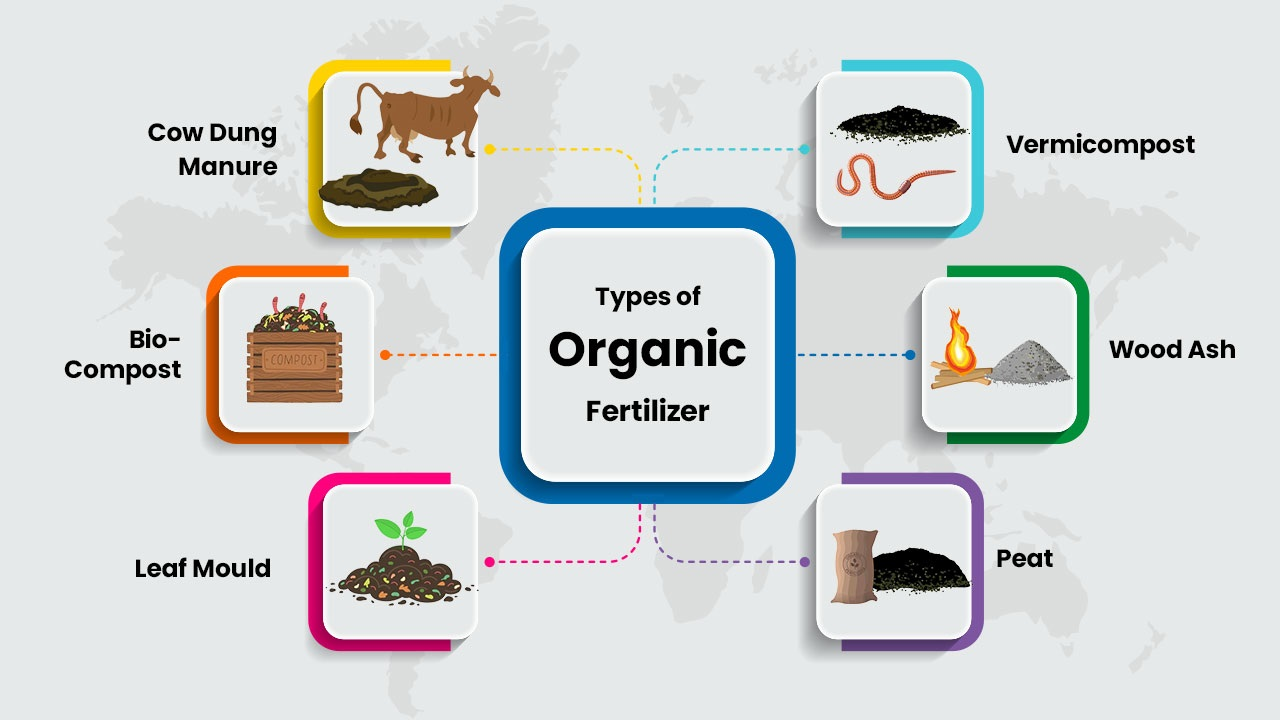

In [2]:
from IPython.display import Image, display
img_path = "/kaggle/input/myfiles/pobierz (1).jpg"
display(Image(filename=img_path))

# **About the Competition**

This is part of the 2025 Kaggle Playground Series, where we get fun datasets to practice machine learning. The goal of *Predicting Optimal Fertilizers* is to pick the best fertilizer for crops based on weather and soil conditions.

**Objective**: Predict up to three fertilizer names for each test case.

**Evaluation**: Uses Mean Average Precision @ 3 (MAP@3). Only the first correct fertilizer counts, ignoring repeats.

**Submission Format**:

id,Fertilizer Name

750000,14-35-14 10-26-26 Urea

750001,10-26-26 Urea DAP

**Timeline**:
- Start: June 1, 2025
- Deadline: June 30, 2025 (11:59 PM UTC)

The Playground Series uses synthetic datasets for quick, real-world-like challenges. Let’s optimize those fertilizer picks! 🌱

# **Import Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, mean_squared_error
import torch.nn as nn

from xgboost import XGBClassifier
import lightgbm as lgb

%matplotlib inline

warnings.filterwarnings('ignore')

# **Evaluation Metric**

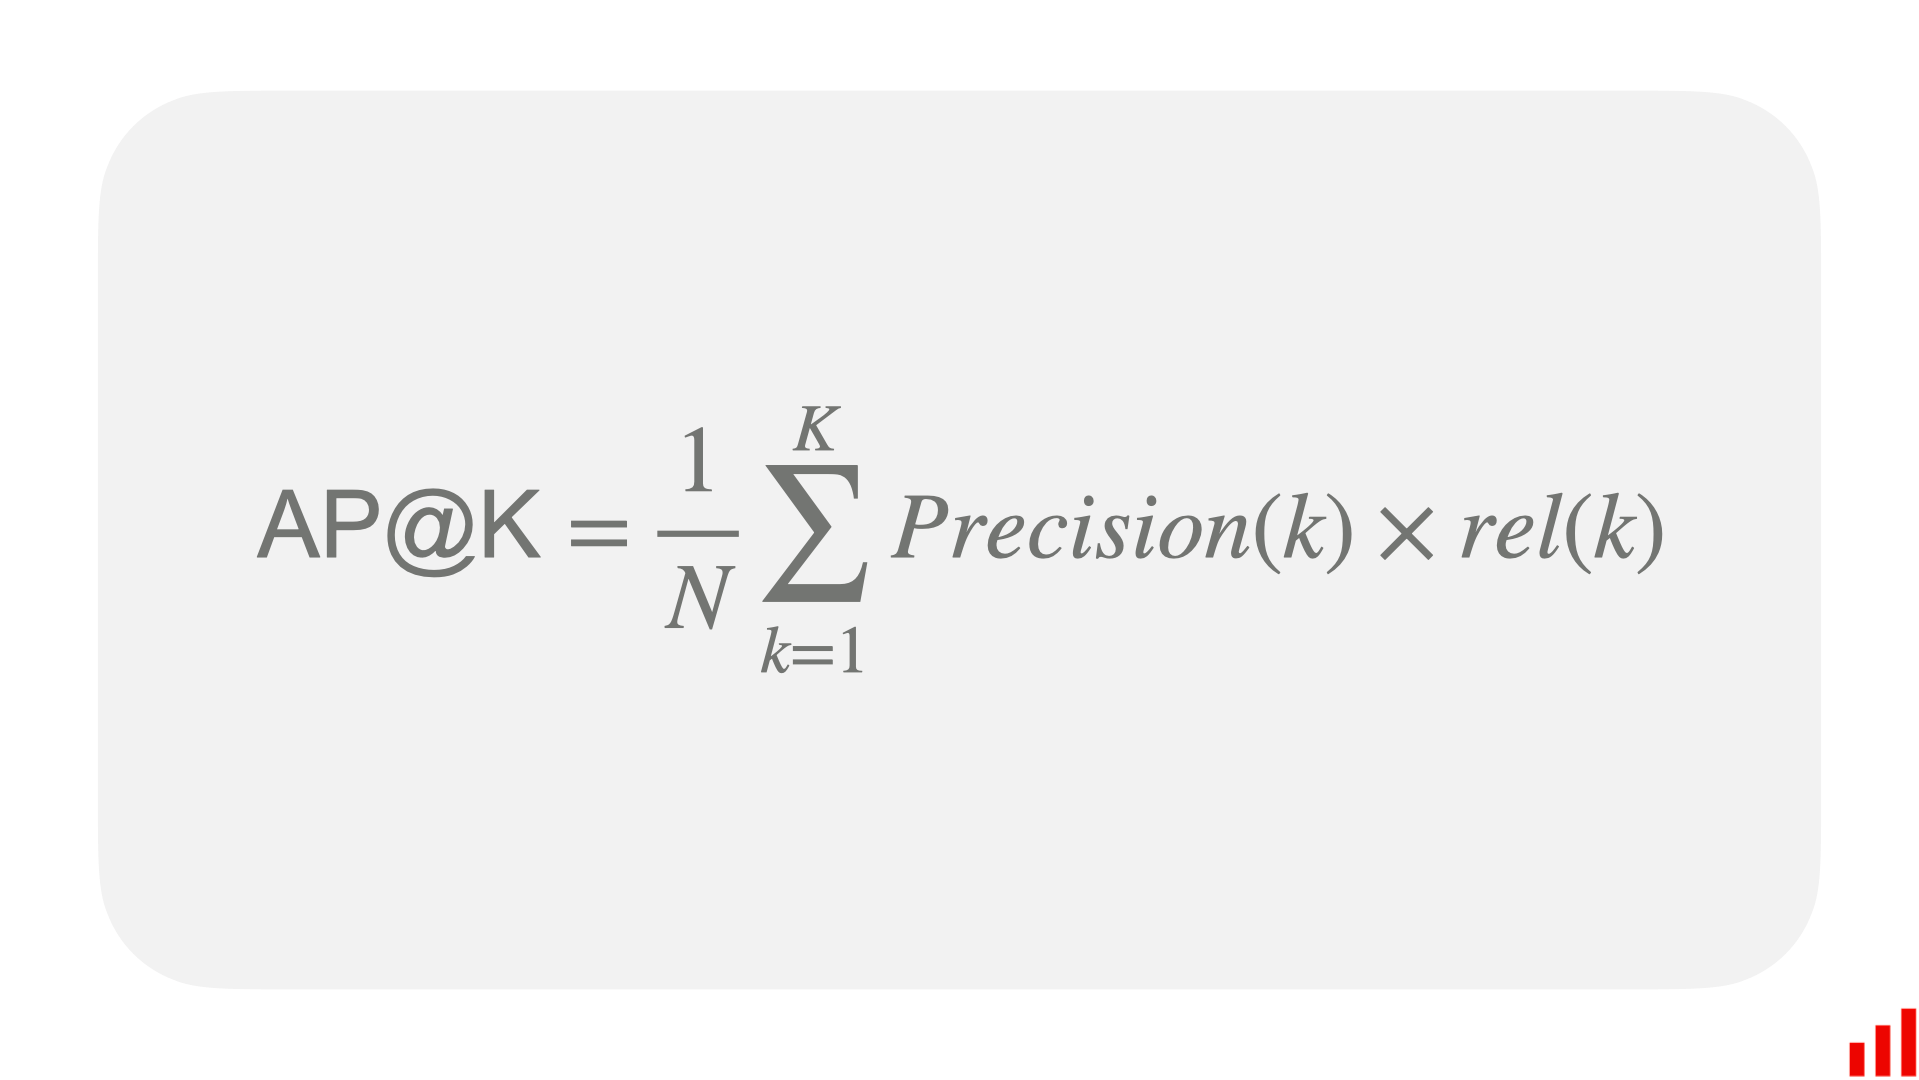

In [4]:
img1_path = '/kaggle/input/myfiles/pobierz.png'
display(Image(filename=img1_path))

# **Loading Dataset**

In [5]:
train_data = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv')
test_data = pd.read_csv('/kaggle/input/playground-series-s5e6/test.csv')
test_submission = pd.read_csv('/kaggle/input/playground-series-s5e6/sample_submission.csv')

# **Data Overview**

In [6]:
print(f'Data Shape: {train_data.shape}')

print(f'\nData Info: ')
train_data.info()

print(f'\nNumerical Features Summary:')
display(train_data.describe().transpose())

print(f'\nFirst 10 rows of the Dataset:')
train_data.head(10)

Data Shape: (750000, 10)

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               750000 non-null  int64 
 1   Temparature      750000 non-null  int64 
 2   Humidity         750000 non-null  int64 
 3   Moisture         750000 non-null  int64 
 4   Soil Type        750000 non-null  object
 5   Crop Type        750000 non-null  object
 6   Nitrogen         750000 non-null  int64 
 7   Potassium        750000 non-null  int64 
 8   Phosphorous      750000 non-null  int64 
 9   Fertilizer Name  750000 non-null  object
dtypes: int64(7), object(3)
memory usage: 57.2+ MB

Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
Temparature,750000.0,31.503565,4.025574,25.0,28.00,32.0,35.00,38.0
Humidity,750000.0,61.038912,6.647695,50.0,55.00,61.0,67.00,72.0
Moisture,750000.0,45.184147,11.794594,25.0,35.00,45.0,55.00,65.0
Nitrogen,750000.0,23.093808,11.216125,4.0,13.00,23.0,33.00,42.0
Potassium,750000.0,9.478296,5.765622,0.0,4.00,9.0,14.00,19.0
Phosphorous,750000.0,21.073227,12.346831,0.0,10.00,21.0,32.00,42.0



First 10 rows of the Dataset:


,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP
5,5,30,59,29,Red,Pulses,10,0,9,20-20
6,6,27,62,53,Sandy,Paddy,26,15,22,28-28
7,7,36,62,44,Red,Pulses,30,12,35,14-35-14
8,8,36,51,32,Loamy,Tobacco,19,17,29,17-17-17
9,9,28,50,35,Red,Tobacco,25,12,16,20-20


In [7]:
#drop id column
train_data.drop('id', axis=1, inplace=True)
test_data.drop('id', axis=1, inplace=True)

In [8]:
#There are no duplicates
train_data.duplicated().value_counts()

False    750000
Name: count, dtype: int64

In [9]:
train_data.nunique()

Temparature        14
Humidity           23
Moisture           41
Soil Type           5
Crop Type          11
Nitrogen           39
Potassium          20
Phosphorous        43
Fertilizer Name     7
dtype: int64

📘 English Description:

This dataset contains environmental and soil information related to different crops and the recommended fertilizer types. Each row represents a unique observation with the following columns:

* id: Unique identifier for each record.

* Temperature: Ambient temperature in degrees Celsius at the time of data collection.

* Humidity: Relative humidity percentage of the environment.

* Moisture: Soil moisture percentage.

* Soil Type: Category of soil in the sample (e.g., Clayey, Sandy, Red, Loamy).

* Crop Type: Type of crop being grown (e.g., Sugarcane, Millets, Barley, etc.).

* Nitrogen: Nitrogen content level in the soil sample (measured in parts per unit, indicative of fertility).

* Potassium: Potassium content level in the soil sample.

* Phosphorous: Phosphorous content level in the soil sample.

* Fertilizer Name: The name or code of the recommended fertilizer based on soil and crop characteristics (e.g., 28-28, DAP, 17-17-17).

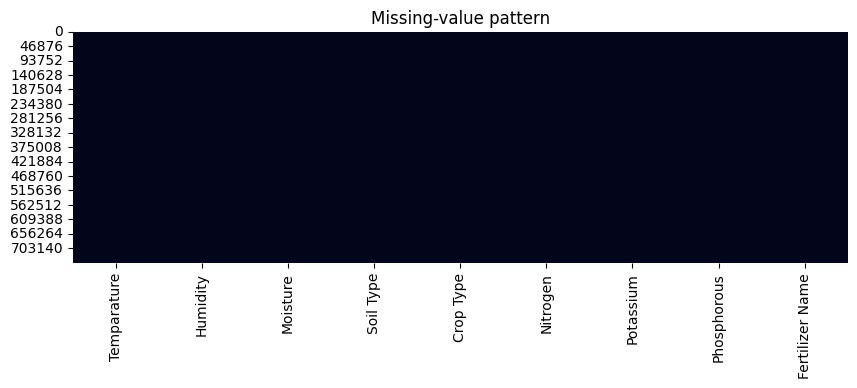

In [10]:
plt.figure(figsize=(10,3))
sns.heatmap(train_data.isna(), cbar=False)
plt.title("Missing‐value pattern"); plt.show()

# **Exploratory Data Analysis**

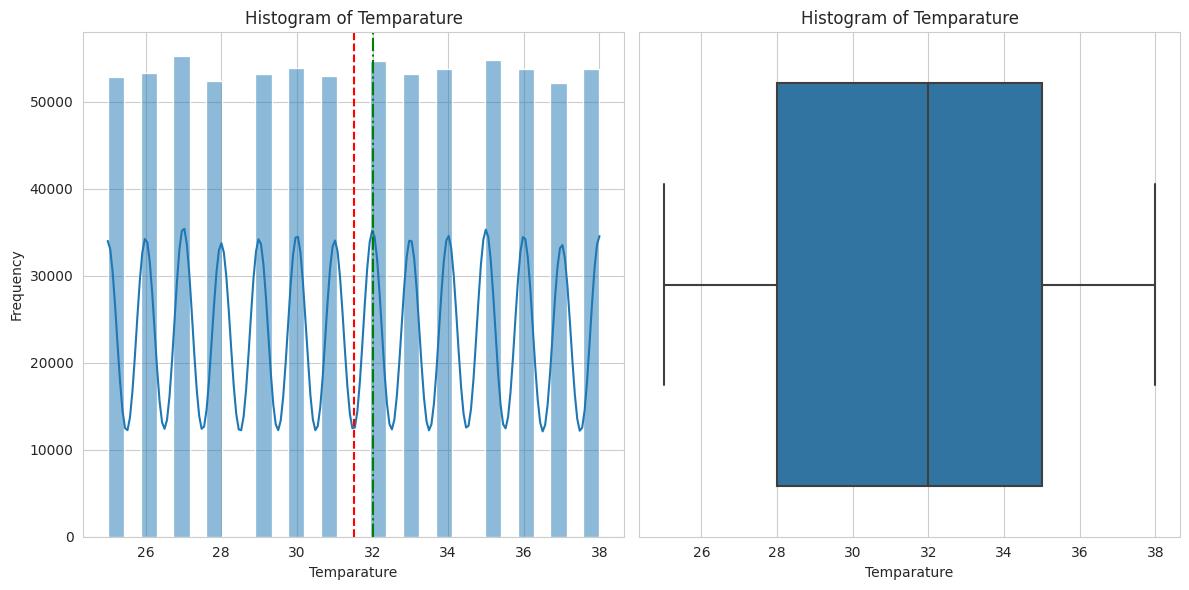


Statistics for Temparature:

Skewness: -0.00

Standard Deviation: 4.03

Variance: 16.21


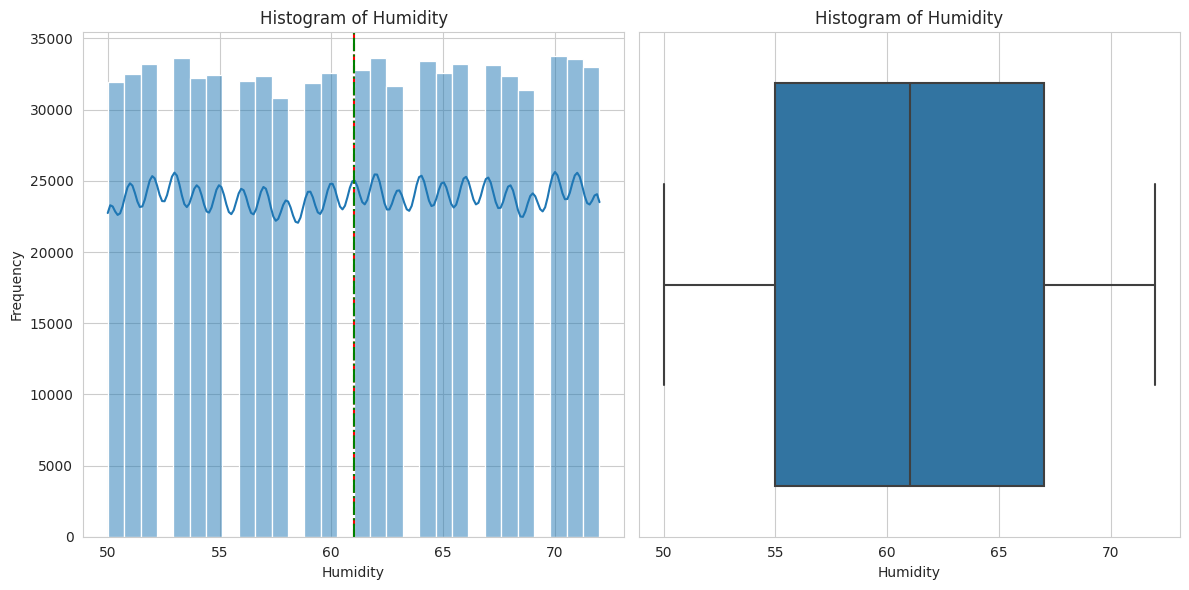


Statistics for Humidity:

Skewness: -0.01

Standard Deviation: 6.65

Variance: 44.19


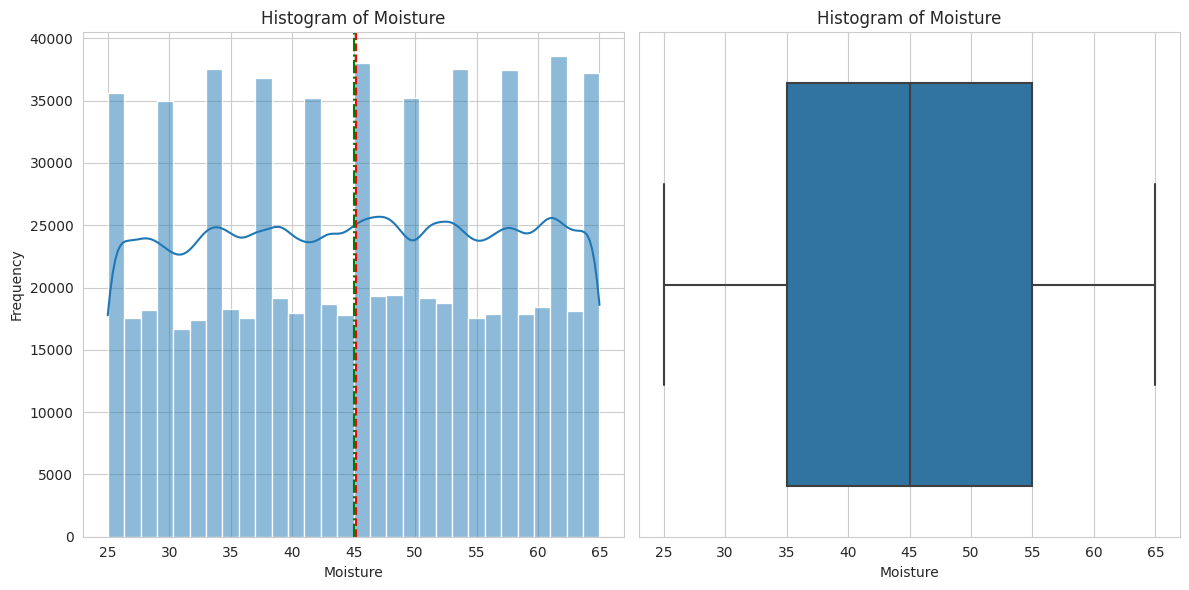


Statistics for Moisture:

Skewness: -0.02

Standard Deviation: 11.79

Variance: 139.11


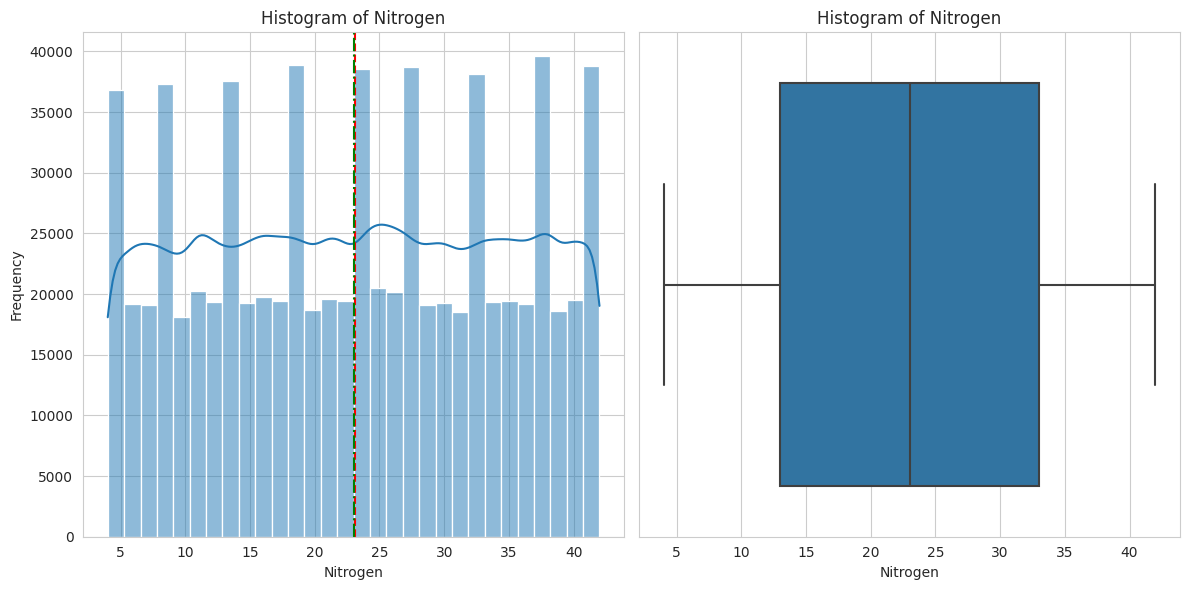


Statistics for Nitrogen:

Skewness: -0.01

Standard Deviation: 11.22

Variance: 125.80


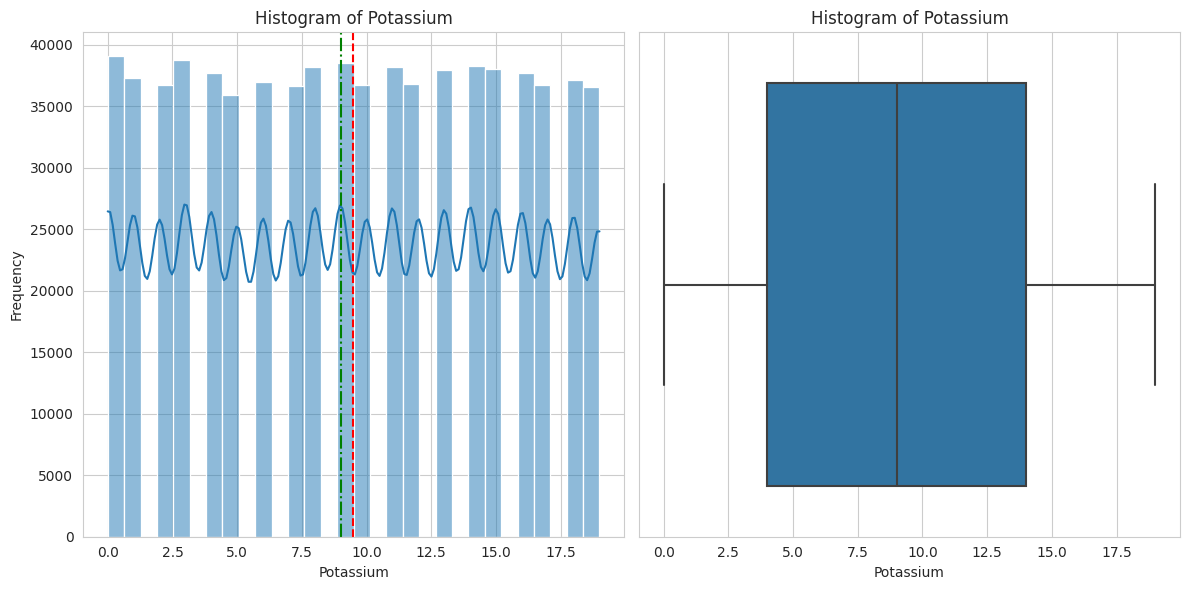


Statistics for Potassium:

Skewness: -0.00

Standard Deviation: 5.77

Variance: 33.24


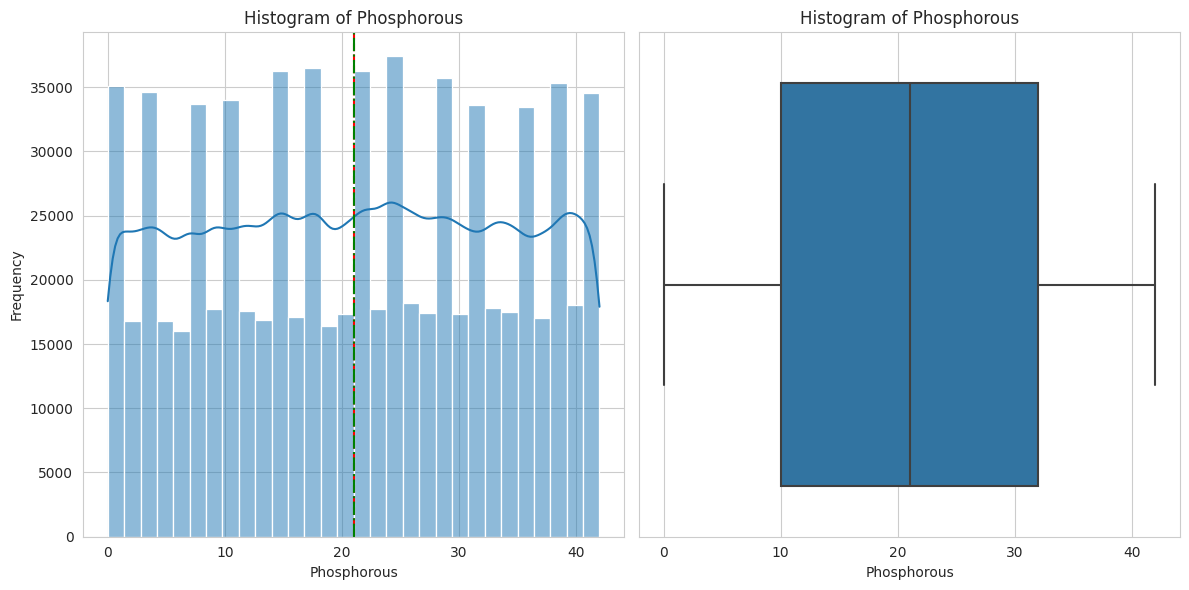


Statistics for Phosphorous:

Skewness: -0.01

Standard Deviation: 12.35

Variance: 152.44


In [11]:
sns.set_style('whitegrid')

numerical_features = train_data.select_dtypes(include=['number'])

for feature in numerical_features:
    plt.figure(figsize=(12, 6))

    #Histogram of feature
    plt.subplot(1,2,1)
    sns.histplot(data=train_data, x=feature, kde=True, bins=30)
    plt.axvline(train_data[feature].mean(), color='r', linestyle='--', label='Mean')
    plt.axvline(train_data[feature].median(), color='g', linestyle='-.', label='Median')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel(f'Frequency')

    #Boxplot of feature
    plt.subplot(1,2,2)
    sns.boxplot(data=train_data, x=feature)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(f'{feature}')
 
    plt.tight_layout()
    plt.show()

    print(f'\nStatistics for {feature}:')
    print(f'\nSkewness: {train_data[feature].skew():.2f}')
    print(f'\nStandard Deviation: {train_data[feature].std():.2f}')
    print(f'\nVariance: {train_data[feature].var():.2f}')
    

## **Categorical Features**

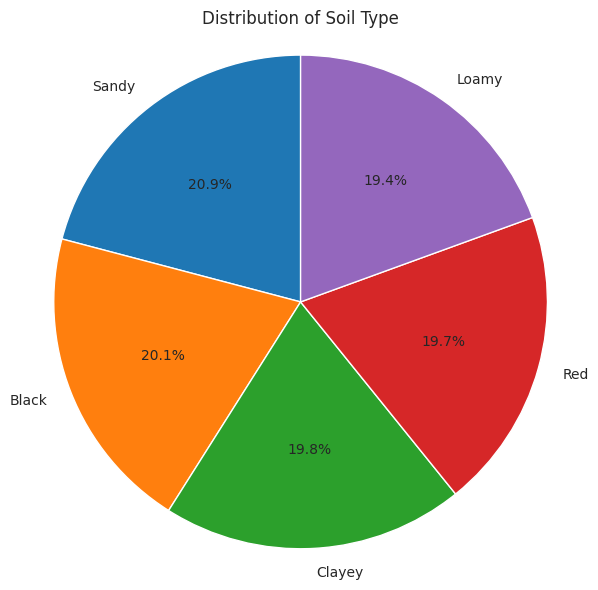


Number of Unique Soil Type: 5

Missing Values in Soil Type: 0


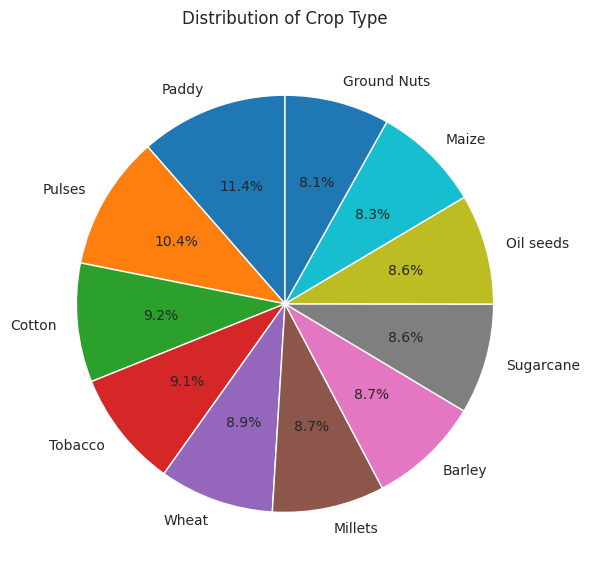


Number of Unique Crop Type: 11

Missing Values in Crop Type: 0


In [12]:
categorical_features = ['Soil Type', 'Crop Type']

for feature in categorical_features:
    counts = train_data[feature].value_counts()

    #Plot pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(x=counts, labels=counts.index, startangle=90, autopct='%1.1f%%')

    plt.title(f'Distribution of {feature}')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    print(f"\nNumber of Unique {feature}: {train_data[feature].nunique()}")
    print(f"\nMissing Values in {feature}: {train_data[feature].isnull().sum()}")

## **KDE Plot**

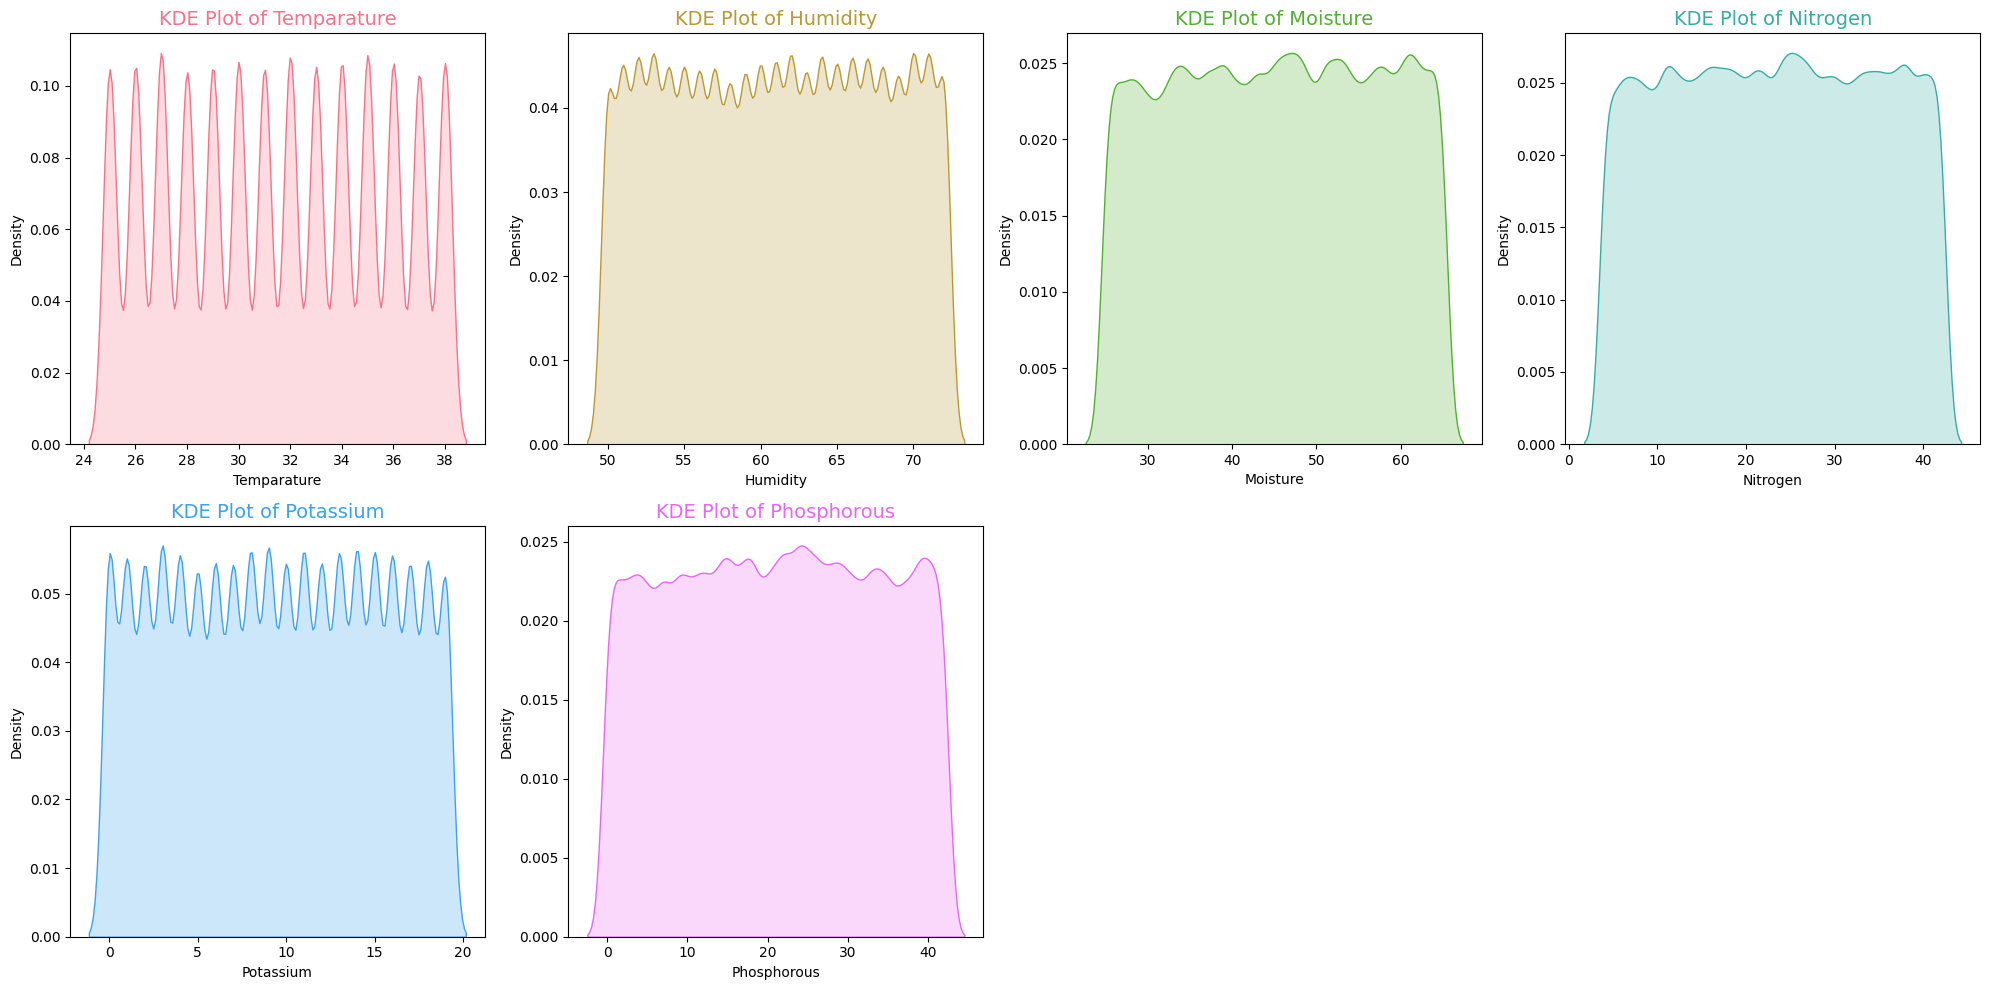

In [13]:
numerical_features = train_data.select_dtypes(include='number').columns
colors = sns.color_palette('husl', len(numerical_features))

sns.reset_defaults()
plt.style.use('default')

rows = -(-len(numerical_features) // 4)
plt.figure(figsize=(20, 5 * rows))

for i, (col, color) in enumerate(zip(numerical_features, colors), 1):
    plt.subplot(rows, 4, i)
    sns.kdeplot(data=train_data, x=col, fill=True, color=color)
    plt.title(f'KDE Plot of {col}', fontsize=14, color=color)
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

## **Scatter Plot**

<Figure size 1200x800 with 0 Axes>

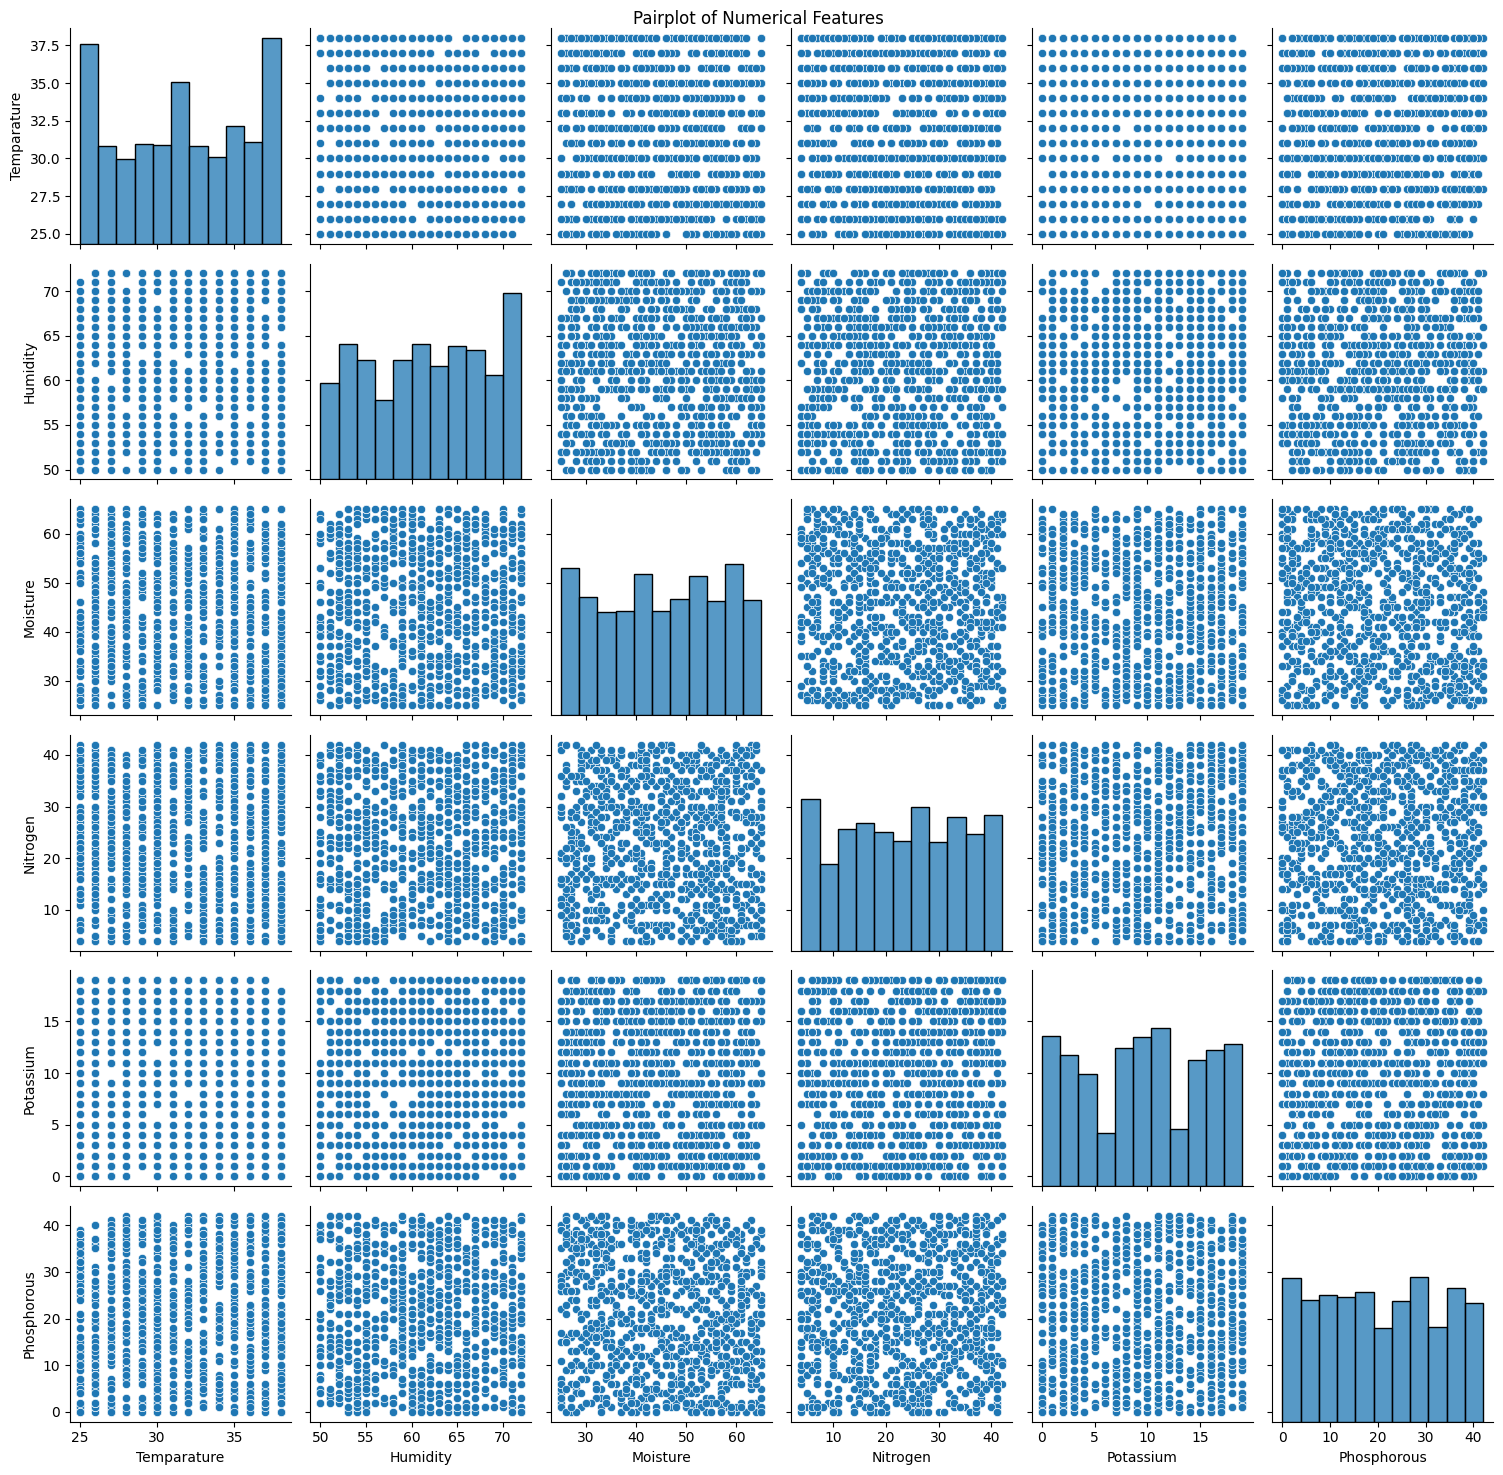

In [14]:
numerical_features = train_data.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.pairplot(data=numerical_features.sample(1000))
plt.suptitle('Pairplot of Numerical Features')
plt.tight_layout()
plt.show()

# **Bivariate Analysis**

## **Numerical Features vs. Label**

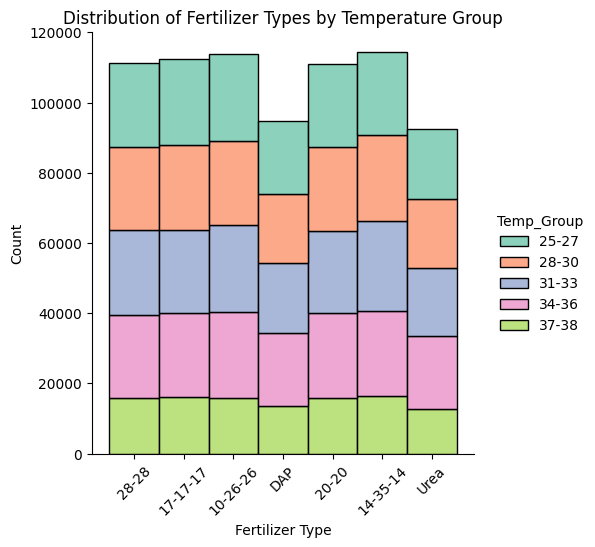

In [15]:
bins = [24, 27, 30, 33, 36, 39]
labels = ['25-27', '28-30', '31-33', '34-36', '37-38']
train_data['Temp_Group'] = pd.cut(train_data['Temparature'], bins=bins, labels=labels)

sns.displot(data=train_data, x='Fertilizer Name', hue='Temp_Group', palette='Set2', multiple='stack')
plt.xticks(rotation=45)

plt.xlabel("Fertilizer Type")
plt.ylabel("Count")
plt.title("Distribution of Fertilizer Types by Temperature Group")
plt.show()

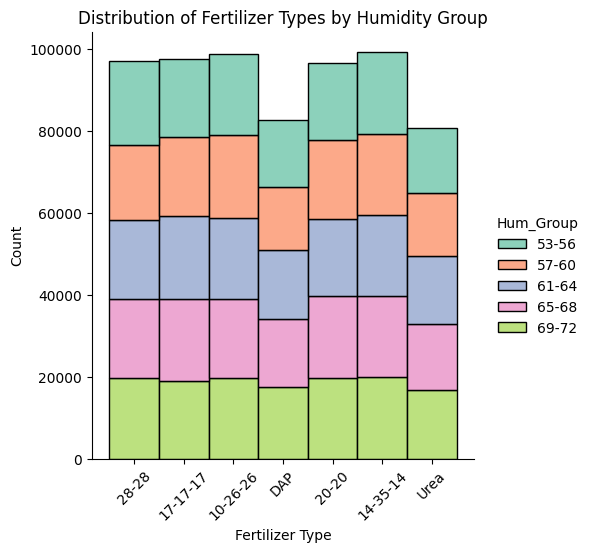

In [16]:
labels = ['53-56', '57-60', '61-64', '65-68', '69-72']
bins = [52, 56, 60, 64, 68, 72]

train_data['Hum_Group'] = pd.cut(train_data['Humidity'], labels=labels, bins=bins)

sns.displot(data=train_data, x='Fertilizer Name', hue='Hum_Group', palette='Set2', multiple='stack')

plt.xticks(rotation=45)
plt.xlabel("Fertilizer Type")
plt.ylabel("Count")
plt.title("Distribution of Fertilizer Types by Humidity Group")
plt.show()

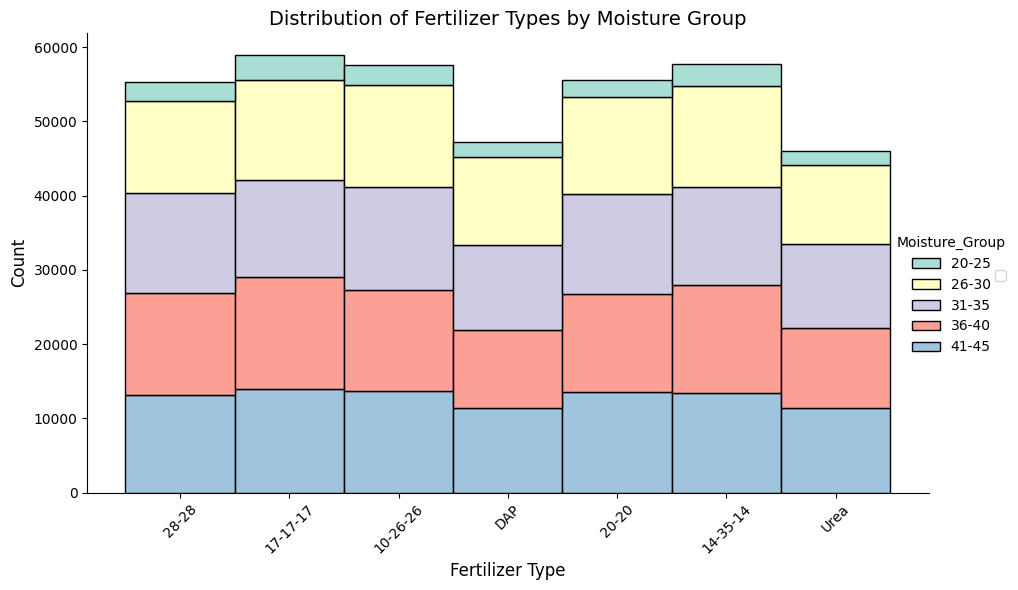

In [17]:
bins = [19, 25, 30, 35, 40, 45]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45']

train_data['Moisture_Group'] = pd.cut(train_data['Moisture'], bins=bins, labels=labels, include_lowest=True)

g = sns.displot(
    data=train_data,
    x='Fertilizer Name',
    hue='Moisture_Group',
    palette='Set3',
    multiple='stack',
    height=6,
    aspect=1.5
)

plt.xticks(rotation=45)
plt.xlabel("Fertilizer Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(bbox_to_anchor=(0.6, 0., 0.5, 0.5))
plt.title("Distribution of Fertilizer Types by Moisture Group", fontsize=14)

plt.tight_layout()
plt.show()

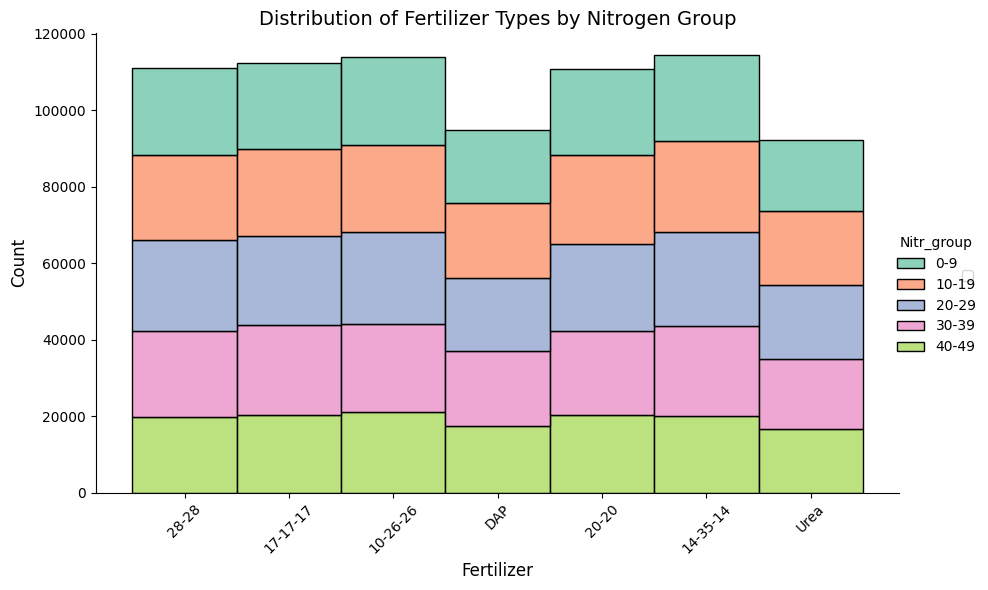

In [18]:
train_data['Nitr_group'] = pd.qcut(train_data['Nitrogen'], q=5, labels=['0-9', '10-19', '20-29', '30-39', '40-49'])

g = sns.displot(
    data = train_data,
    x='Fertilizer Name',
    hue='Nitr_group',
    palette='Set2',
    multiple='stack',
    height=6,
    aspect=1.5
)

plt.xticks(rotation=45)
plt.xlabel('Fertilizer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(bbox_to_anchor=(0.6, 0., 0.5, 0.5))
plt.title("Distribution of Fertilizer Types by Nitrogen Group", fontsize=14)

plt.tight_layout()
plt.show()

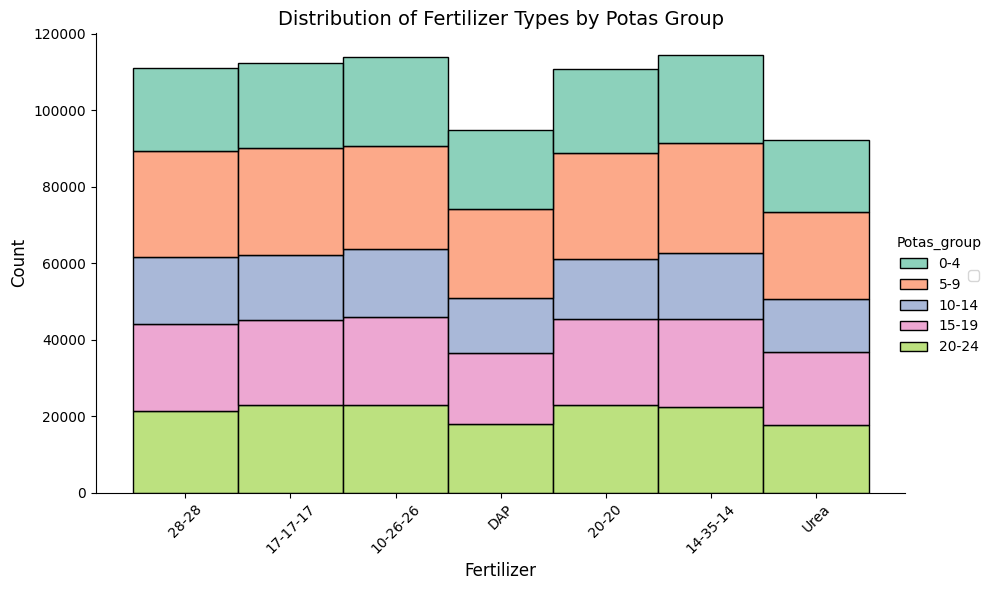

In [19]:
train_data['Potas_group'] = pd.qcut(train_data['Potassium'], q=5, labels=['0-4', '5-9', '10-14', '15-19', '20-24'])

g = sns.displot(
    data = train_data,
    x='Fertilizer Name',
    hue='Potas_group',
    palette='Set2',
    multiple='stack',
    height=6,
    aspect=1.5
)

plt.xticks(rotation=45)
plt.xlabel('Fertilizer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(bbox_to_anchor=(0.6, 0., 0.5, 0.5))
plt.title("Distribution of Fertilizer Types by Potas Group", fontsize=14)

plt.tight_layout()
plt.show()

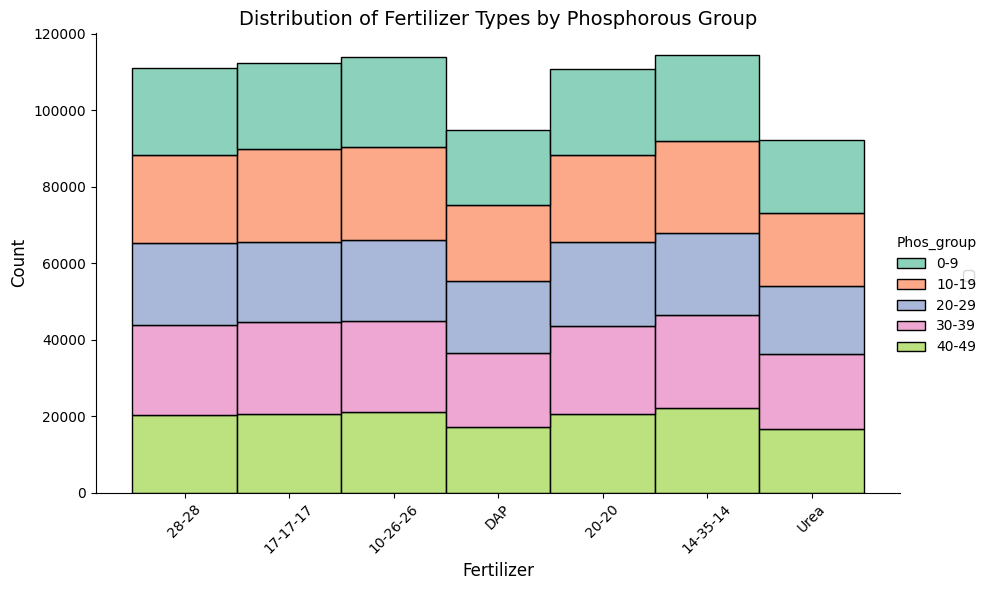

In [20]:
train_data['Phos_group'] = pd.qcut(train_data['Phosphorous'], q=5, labels=['0-9', '10-19', '20-29', '30-39', '40-49'])

g = sns.displot(
    data = train_data,
    x='Fertilizer Name',
    hue='Phos_group',
    palette='Set2',
    multiple='stack',
    height=6,
    aspect=1.5
)

plt.xticks(rotation=45)
plt.xlabel('Fertilizer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(bbox_to_anchor=(0.6, 0., 0.5, 0.5))
plt.title("Distribution of Fertilizer Types by Phosphorous Group", fontsize=14)

plt.tight_layout()
plt.show()

# **Heatmap**

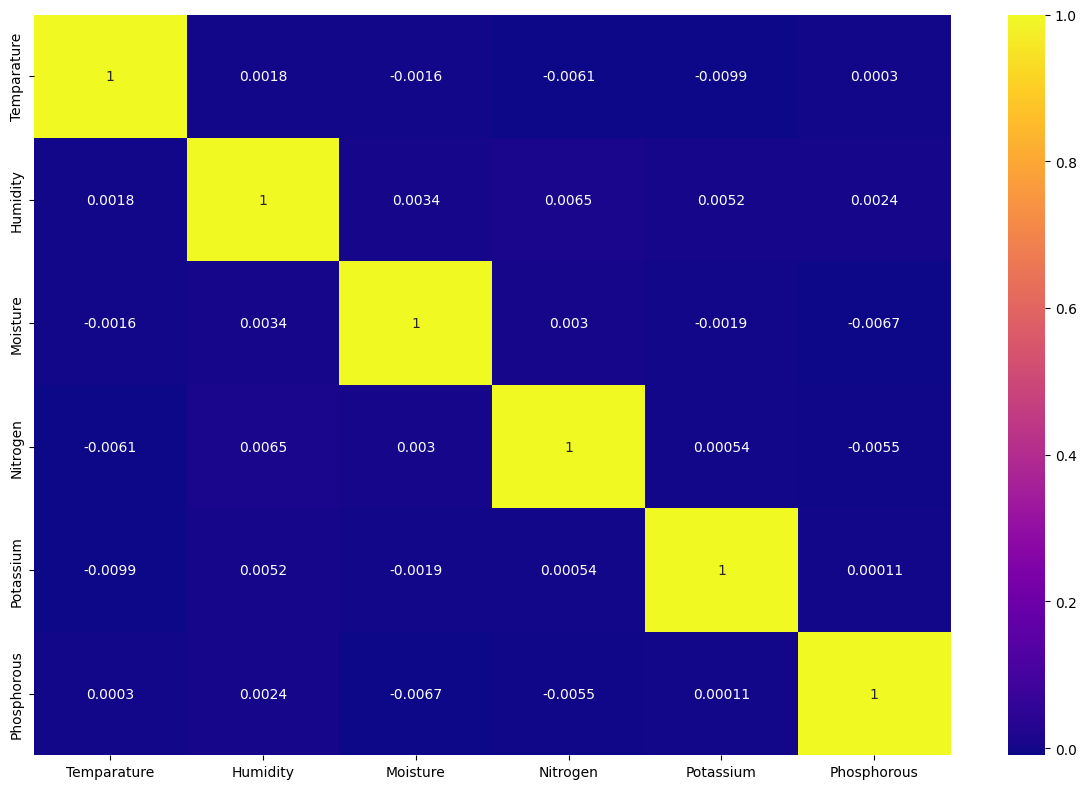

In [21]:
plt.figure(figsize=(12, 8))
train_data = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv')
train_data.drop('id', axis=1, inplace=True)

numerical_features = train_data.select_dtypes(include='number').columns
corr = train_data[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap='plasma')

plt.tight_layout()
plt.show()

# **Feature Engineering**

In [22]:
num_cols = train_data.select_dtypes(include='number').columns
cat_cols = train_data.select_dtypes(include='object').columns

In [23]:
for df in [train_data, test_data]:
    df['row_mean'] = df[num_cols].mean(axis=1)
    df['row_std'] = df[num_cols].std(axis=1)
    df['row_min'] = df[num_cols].min(axis=1)
    df['row_max'] = df[num_cols].max(axis=1)

# **Label Encoding**

In [24]:
for n in cat_cols:
    print(f'Number of unique values in {n}: {train_data[n].nunique()}')

Number of unique values in Soil Type: 5
Number of unique values in Crop Type: 11
Number of unique values in Fertilizer Name: 7


In [25]:
from sklearn.preprocessing import LabelEncoder

fertilizer_encoder = ''

for feature in cat_cols:
    label_enc = LabelEncoder()
    if feature != 'Fertilizer Name':
        train_data[feature] = label_enc.fit_transform(train_data[feature])
        test_data[feature] = label_enc.transform(test_data[feature])
    else:
        train_data['target'] = label_enc.fit_transform(train_data[feature]) 
        fertilizer_encoder = label_enc

In [26]:
train_data.head(5)

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,row_mean,row_std,row_min,row_max,target
0,37,70,36,1,8,36,4,5,28-28,31.333333,24.541122,4,70,4
1,27,69,65,4,4,30,6,18,28-28,35.833333,25.576682,6,69,4
2,29,63,32,4,4,24,12,16,17-17-17,29.333333,18.151217,12,63,2
3,35,62,54,4,0,39,12,4,10-26-26,34.333333,22.774254,4,62,0
4,35,58,43,3,6,37,2,16,DAP,31.833333,19.934058,2,58,5


# **XGBoost**

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import label_ranking_average_precision_score
from xgboost import XGBClassifier

X = train_data.drop(['Fertilizer Name', 'target'], axis=1)
y = train_data['target']
num_classes = y.nunique()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=num_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

val_proba = model.predict_proba(X_val)

y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))

map3 = label_ranking_average_precision_score(y_val_bin, val_proba)
print(f"Validation MAP@3: {map3:.5f}")

Validation MAP@3: 0.41813


In [28]:
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=7, num_parallel_tree=None, ...)

In [29]:
test_proba = model.predict_proba(test_data)
top3_preds = np.argsort(test_proba, axis=1)[:, -3:][:, ::-1]

In [33]:
submission = pd.DataFrame({
    'id': test_submission['id'],
    'Fertilizer Name': [
        ' '.join([fertilizer_encoder.inverse_transform([i])[0] for i in row])
        for row in top3_preds
    ]
})

In [36]:
submission.to_csv('submission.csv', index=False)